In [1]:
import pandas as pd
import numpy as np

In [2]:
filename ='diabetes_dataset.csv'
df = pd.read_csv(filename)
df.head(1)

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1


In [4]:
df['systolic_diastolic_ratio'] = df['systolic_bp'] / df['diastolic_bp']
df['hdl_ldl_ratio'] = df['hdl_cholesterol'] / df['ldl_cholesterol']
df['glucose_after_eating_to_fasting_ratio'] = df['glucose_postprandial'] / df['glucose_fasting']
df ['bmi_to_age_ratio'] = df['bmi'] / df['age']
df['bmi_cholesterol_ratio'] = df['bmi'] / df['cholesterol_total']

In [5]:
input_cols = ['age', 'gender','smoking_status', 'alcohol_consumption_per_week',
       'sleep_hours_per_day' , 'family_history_diabetes', 'hypertension_history',
       'cardiovascular_history', 'bmi','cholesterol_total' , 'triglycerides', 'insulin_level', 'hba1c', 
       'physical_activity_minutes_per_week', 'diet_score',
       'systolic_diastolic_ratio', 'hdl_ldl_ratio',
       'glucose_after_eating_to_fasting_ratio', 'bmi_to_age_ratio',
       'bmi_cholesterol_ratio']

target_col = 'diabetes_stage'

In [6]:
numerical_cols = df[input_cols].select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df[input_cols].select_dtypes(include=['object']).columns.tolist()

In [7]:
from sklearn.model_selection import train_test_split
X = df[input_cols]
y = df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
X_train.shape, X_test.shape

((90000, 20), (10000, 20))

In [8]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe.fit(X_train[cat_cols])
ohe.categories_

[array(['Female', 'Male', 'Other'], dtype=object),
 array(['Current', 'Former', 'Never'], dtype=object)]

In [9]:
X_train_ohe = ohe.transform(X_train[cat_cols])
X_test_ohe = ohe.transform(X_test[cat_cols])

In [10]:
input_cols_final = numerical_cols + ohe.get_feature_names_out(cat_cols).tolist()

In [11]:
X_train_final = pd.DataFrame(X_train_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_train.index)
X_train_final[numerical_cols] = X_train[numerical_cols]
X_test_final = pd.DataFrame(X_test_ohe, columns=ohe.get_feature_names_out(cat_cols), index=X_test.index)
X_test_final[numerical_cols] = X_test[numerical_cols]
X_train_final.head()

,gender_Female,gender_Male,gender_Other,smoking_status_Current,smoking_status_Former,smoking_status_Never,age,alcohol_consumption_per_week,sleep_hours_per_day,family_history_diabetes,...,triglycerides,insulin_level,hba1c,physical_activity_minutes_per_week,diet_score,systolic_diastolic_ratio,hdl_ldl_ratio,glucose_after_eating_to_fasting_ratio,bmi_to_age_ratio,bmi_cholesterol_ratio
51994,1.0,0.0,0.0,0.0,0.0,1.0,67,2,8.9,0,...,93,14.90,5.86,34,5.0,2.015385,0.405405,1.731183,0.434328,0.125431
77540,1.0,0.0,0.0,0.0,0.0,1.0,39,1,7.1,0,...,129,3.49,6.82,95,8.6,1.739130,0.420168,1.542857,0.607692,0.119697
16382,1.0,0.0,0.0,1.0,0.0,0.0,36,5,6.1,0,...,167,15.47,7.10,419,5.0,1.585714,0.650000,1.596491,0.691667,0.141477
83439,1.0,0.0,0.0,0.0,0.0,1.0,62,1,7.2,0,...,112,13.97,7.50,55,2.6,1.686047,0.388350,1.458015,0.574194,0.189362
61618,1.0,0.0,0.0,1.0,0.0,0.0,31,3,6.8,0,...,98,7.59,7.40,138,6.1,1.541667,0.343511,1.660714,1.054839,0.151389


In [12]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

In [27]:
model = xgb.XGBClassifier(
    n_estimators=200,     # number of trees 
    random_state=42
)

# Train
model.fit(X_train_final, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [28]:
model.score(X_test_final, y_test_enc)

0.8713

In [30]:
def max_depth_error(md):
    model = xgb.XGBClassifier(
        n_estimators = 200,
        max_depth = md,
        random_state = 42
    )
    model.fit(X_train_final, y_train_enc)
    error = 1 - model.score(X_test_final, y_test_enc)
    return {'max_depth': md, 'error': error}

In [31]:
errors_df = pd.DataFrame([max_depth_error(md) for md in range(1,30)])
errors_df.head()

,max_depth,error
0,1,0.1272
1,2,0.1256
2,3,0.1247
3,4,0.1258
4,5,0.1279


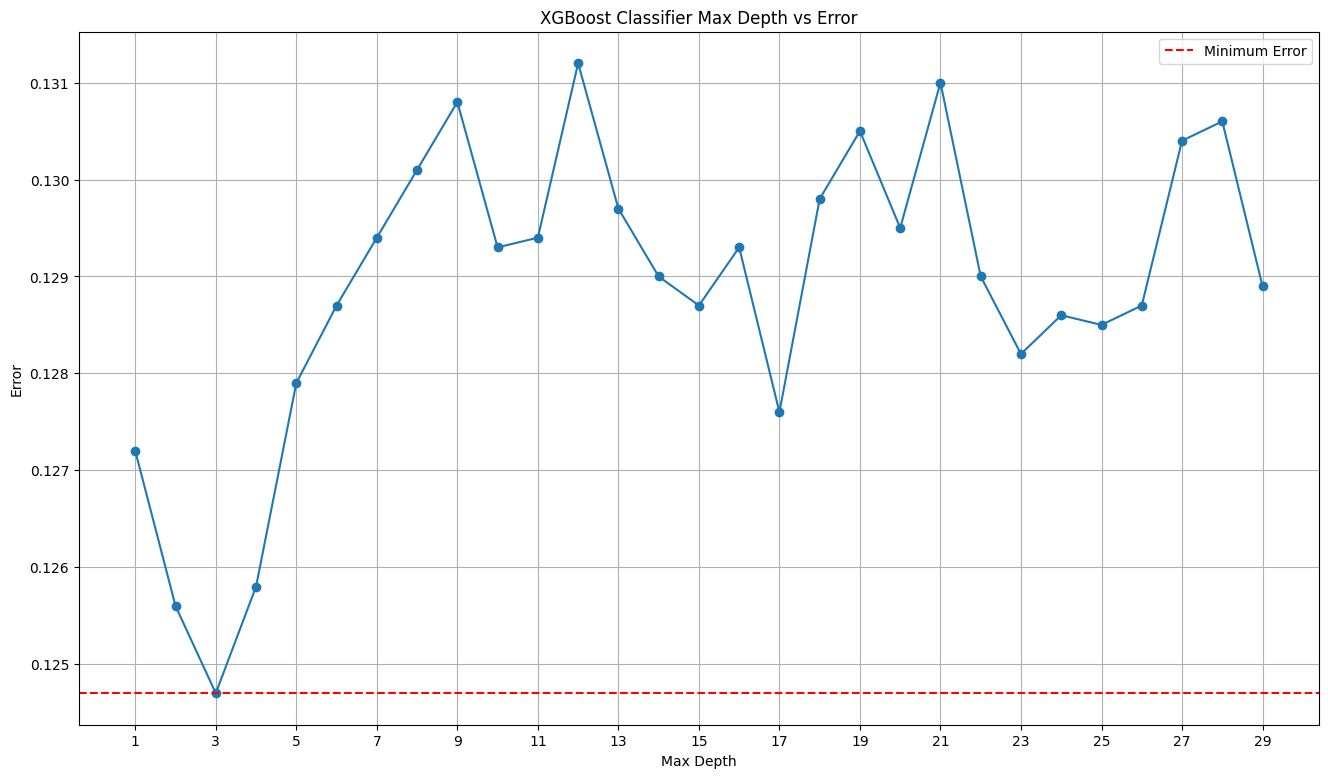

In [32]:
import matplotlib.pyplot as plt
plt.figure(figsize=(16,9))
plt.plot(errors_df['max_depth'], errors_df['error'], marker = 'o')
plt.title('XGBoost Classifier Max Depth vs Error')
plt.xlabel('Max Depth')
plt.ylabel('Error')
plt.xticks(np.arange(1, 30, 2))
plt.axhline(y=errors_df['error'].min(), color='r', linestyle='--', label='Minimum Error')
plt.grid()
plt.legend()
plt.show()

In [41]:
model = xgb.XGBClassifier(
    n_estimators=200,     # number of trees 
    random_state=42,
    max_depth = 3
)

# Train
model.fit(X_train_final, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [40]:
model.score(X_test_final, y_test_enc)

0.8753

In [42]:
def learning_rate_error(lr):
    model = xgb.XGBClassifier(
        n_estimators = 200,
        max_depth = 3,
        random_state =42,
        learning_rate = lr
    )
    model.fit(X_train_final, y_train_enc)
    error = 1 - model.score(X_test_final, y_test_enc)
    return {'learning_rate': lr, 'error': error}

In [46]:
lrs = np.arange(0.01, 0.11, 0.005).round(2).tolist()
lr_errors_df = pd.DataFrame([learning_rate_error(lr) for lr in lrs])
lr_errors_df.head()

,learning_rate,error
0,0.01,0.1289
1,0.02,0.1282
2,0.02,0.1282
3,0.02,0.1282
4,0.03,0.1269


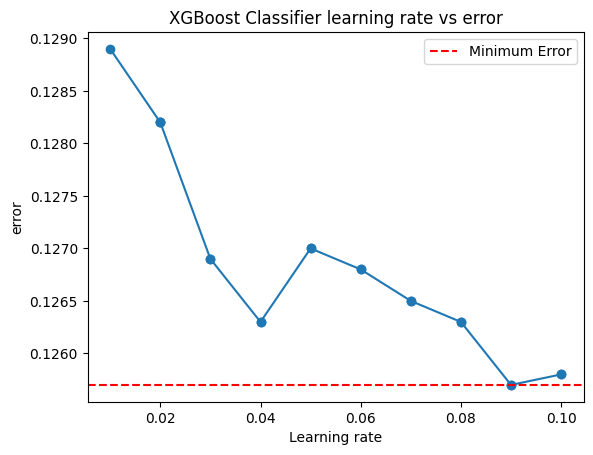

In [48]:
plt.plot(lr_errors_df['learning_rate'], lr_errors_df['error'], marker = 'o')
plt.title('XGBoost Classifier learning rate vs error')
plt.xlabel('Learning rate')
plt.ylabel('error')
plt.axhline(y=lr_errors_df['error'].min(), color='r', linestyle='--', label='Minimum Error')
plt.legend()
plt.show()

In [49]:
model = xgb.XGBClassifier(
    n_estimators=200,     # number of trees 
    random_state=42,
    max_depth = 3,
    learning_rate = 0.09
)

# Train
model.fit(X_train_final, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [50]:
model.score(X_test_final, y_test_enc)

0.8743

In [51]:
# the loss increased 
model = xgb.XGBClassifier(
    n_estimators=200,     # number of trees 
    random_state=42,
    max_depth = 3
)

# Train
model.fit(X_train_final, y_train_enc)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [54]:
print(f"Final Model Accuracy: {model.score(X_test_final, y_test_enc)*100} %")

Final Model Accuracy: 87.53 %
